# QQQ (Invesco QQQ Trust)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

C:\Users\niush\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
file_path = "QQQ_categorized_data.csv"

categorized_df = pd.read_csv(file_path, delimiter=',')

# Bivariate  Analysis

In [3]:
# Assuming the DataFrame is named df and the relevant columns are ['Volume', 'Open', 'Close', 'High', 'Low']
columns_to_check = ['Open', 'Close', 'High', 'Low']

# Columns to analyze correlation
all_columns_to_check = ['Volume', 'Open', 'Close', 'High', 'Low']  # Include Volume and price-related fields


Scatter plot

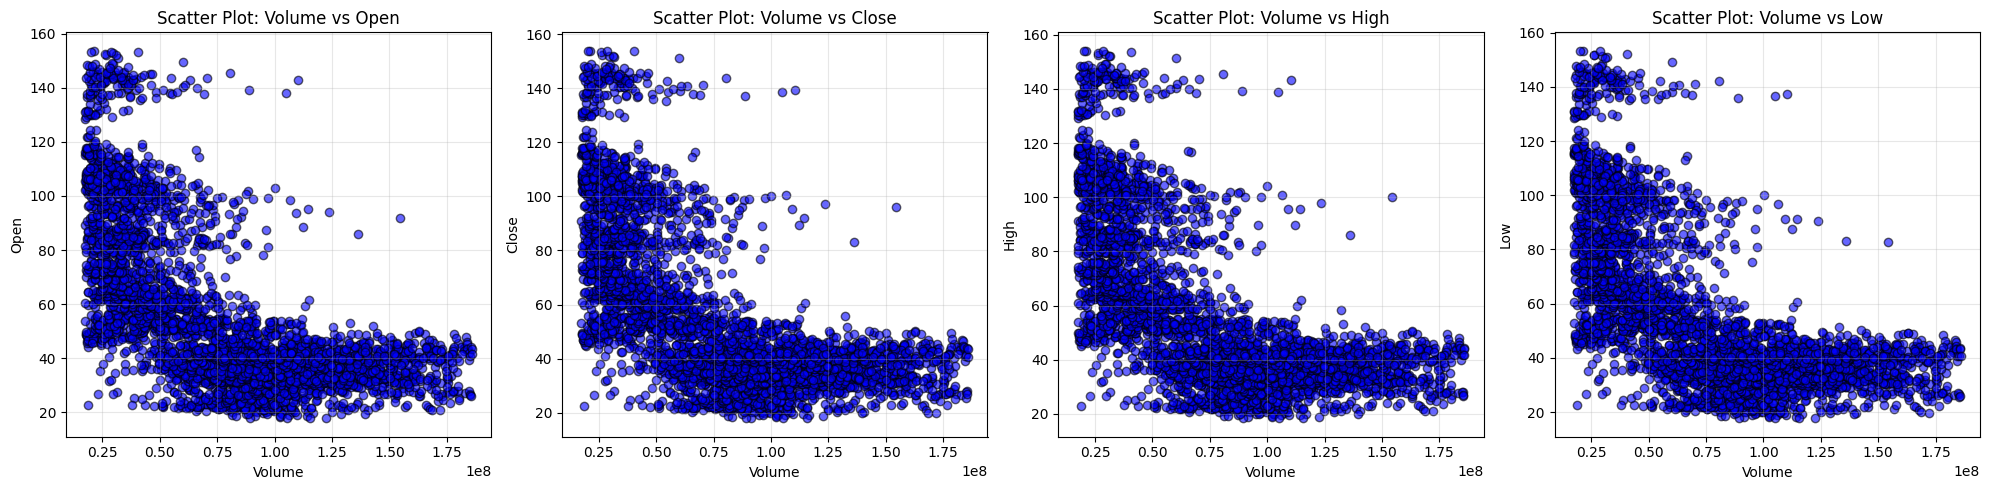

In [4]:
# Create a figure with subplots
fig, axes = plt.subplots(1, len(columns_to_check), figsize=(20, 5))  # 1 row, 4 columns

# Loop through each column and plot Scatter Plot for Volume vs each column
for i, column in enumerate(columns_to_check):
    axes[i].scatter(categorized_df['Volume'], categorized_df[column], alpha=0.6, c='blue', edgecolor='black')
    axes[i].set_title(f"Scatter Plot: Volume vs {column}")
    axes[i].set_xlabel("Volume")
    axes[i].set_ylabel(column)
    axes[i].grid(alpha=0.3)

# Adjust layout to make it visually appealing
plt.tight_layout()
plt.show()

Regression plot

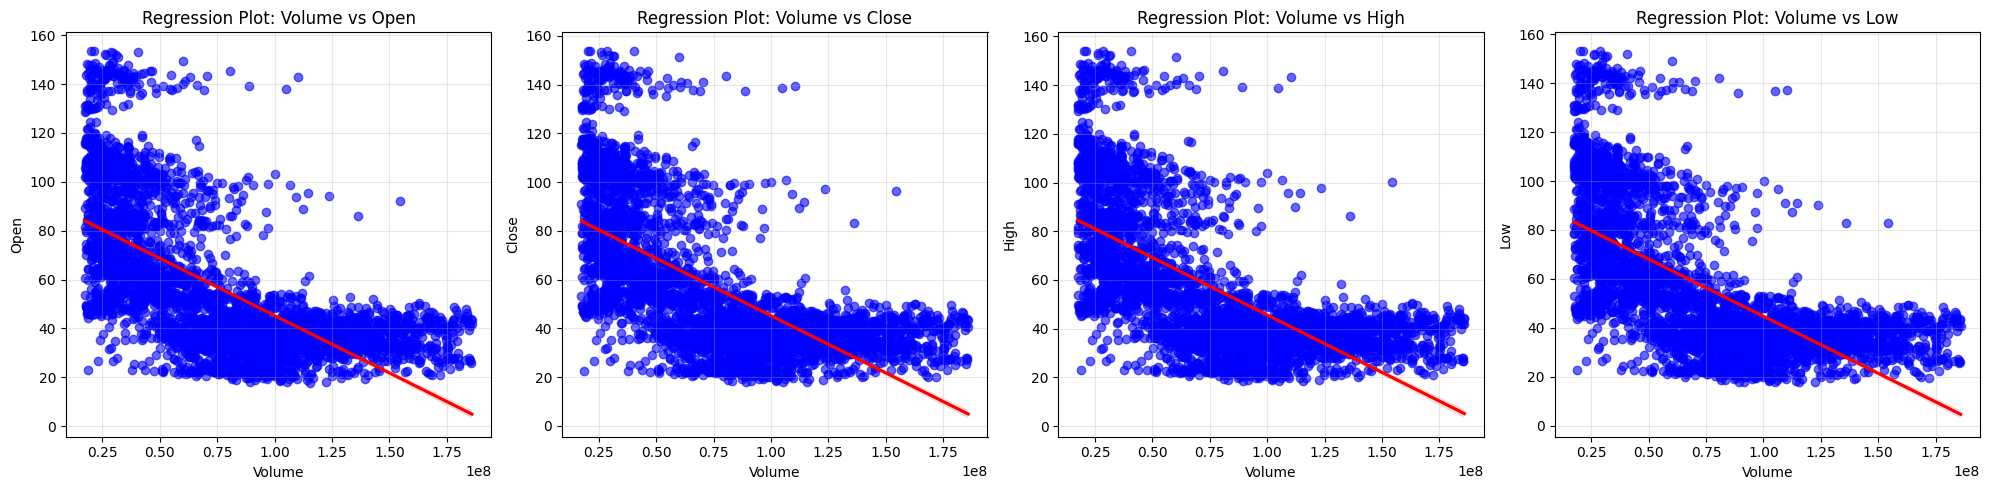

In [5]:
# Create regression plots to analyze relationships between Volume and other fields
fig, axes = plt.subplots(1, len(columns_to_check), figsize=(20, 5))  

# Loop through and plot regression for Volume vs each column
for i, column in enumerate(columns_to_check):
    sns.regplot(
        x='Volume', y=column, data=categorized_df, 
        ax=axes[i], 
        scatter_kws={'alpha': 0.6, 'color': 'blue'},  
        line_kws={'color': 'red'}  
    )
    axes[i].set_title(f"Regression Plot: Volume vs {column}")  
    axes[i].set_xlabel("Volume")  
    axes[i].set_ylabel(column)  
    axes[i].grid(alpha=0.3)  

# Adjust layout for better visualization
plt.tight_layout()
plt.show()

Heatmap

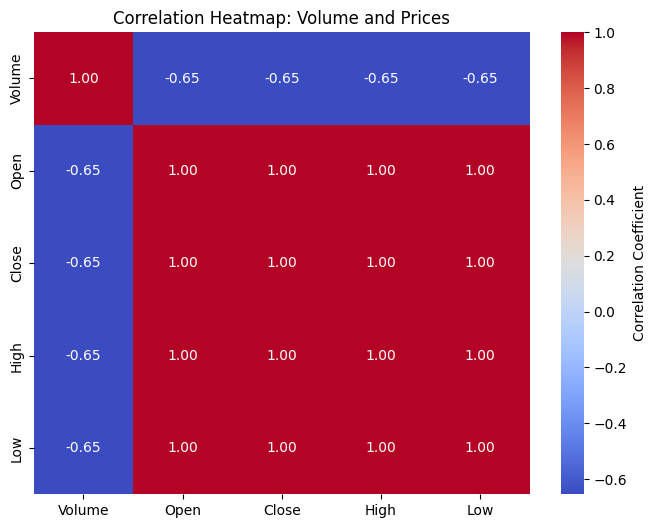

In [6]:
# Compute and plot a heatmap for correlation between Volume and price fields
plt.figure(figsize=(8, 6))  
correlation_matrix = categorized_df[all_columns_to_check].corr()  
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f",  # Format values to 2 decimal places
    cbar_kws={'label': 'Correlation Coefficient'}  
)
plt.title("Correlation Heatmap: Volume and Prices")  
plt.show()

Pair plot

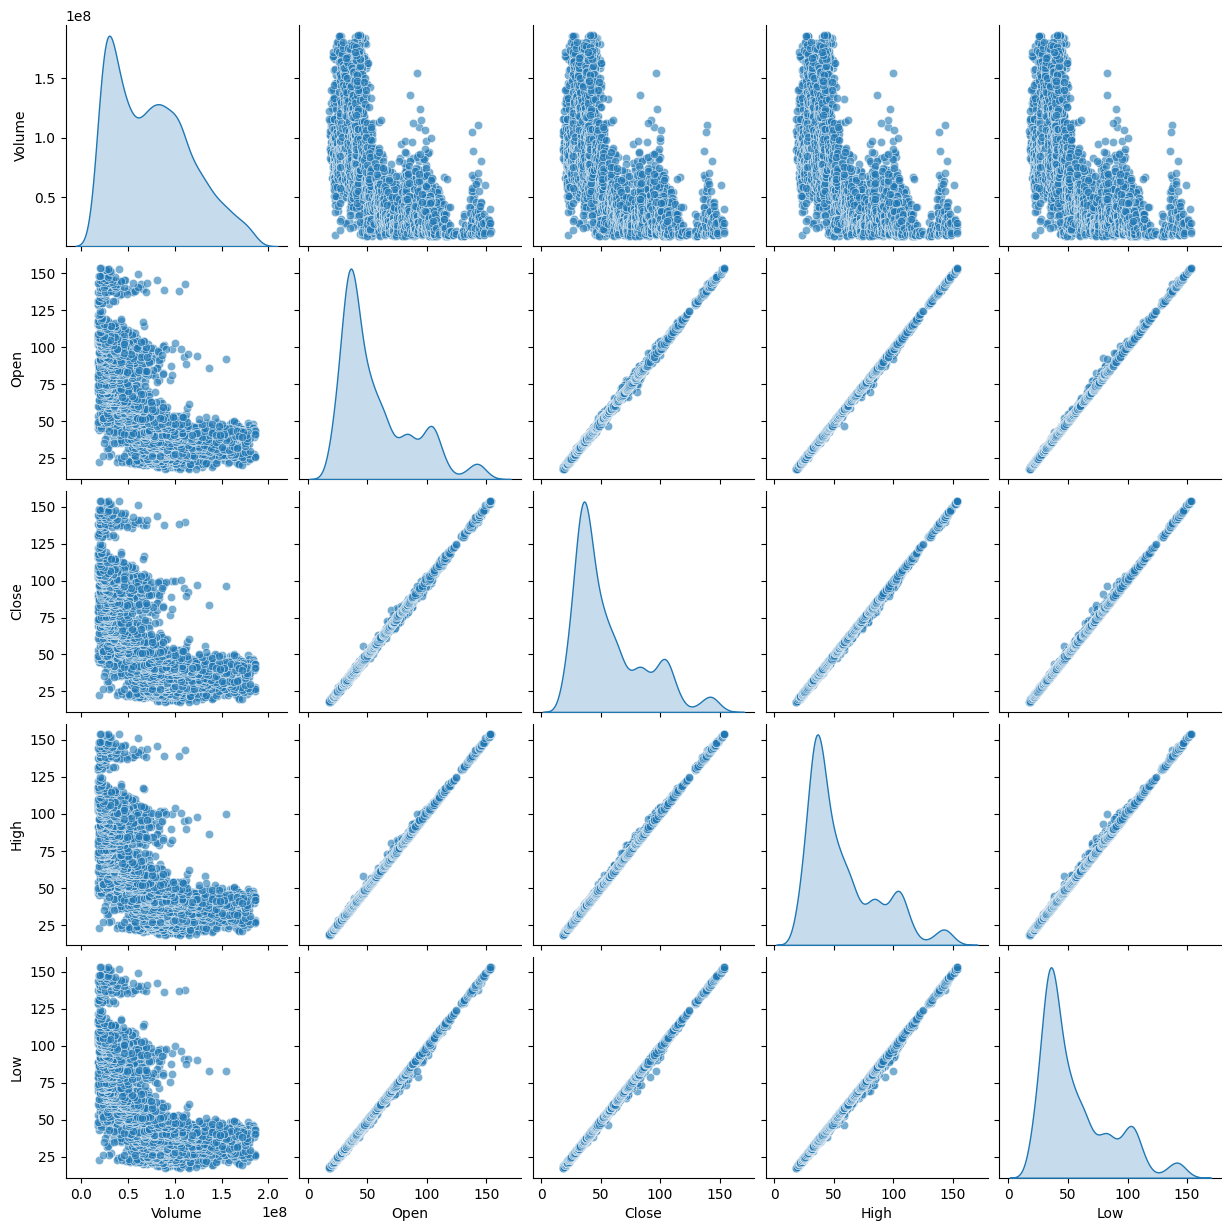

In [7]:
sns.pairplot(categorized_df[['Volume', 'Open', 'Close', 'High', 'Low']], diag_kind='kde', plot_kws={'alpha': 0.6})
plt.show()

2D KDE plot

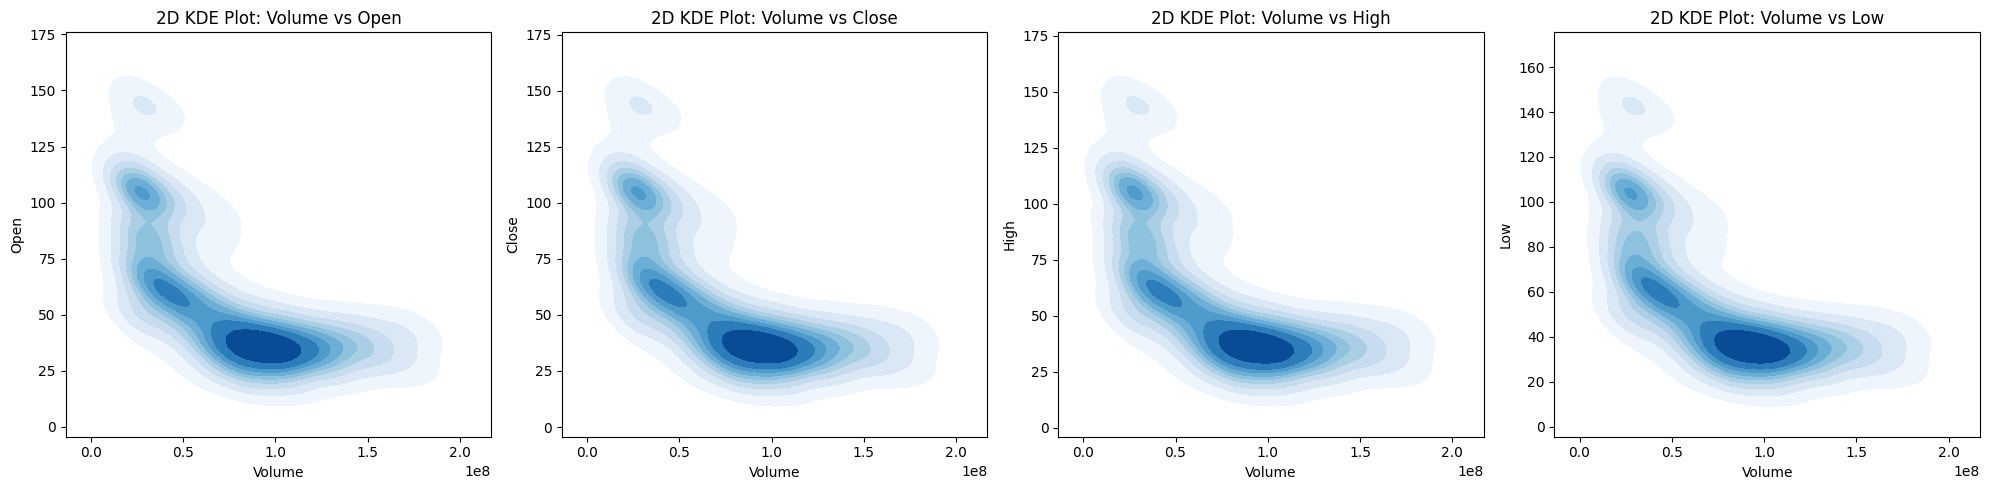

In [8]:
# Create subplots for 2D KDE Plots
fig, axes = plt.subplots(1, len(columns_to_check), figsize=(20, 5))  # 1 row, 4 columns

# Loop through each column and plot 2D KDE for Volume vs each column
for i, column in enumerate(columns_to_check):
    sns.kdeplot(
        x='Volume', y=column, data=categorized_df,  # Assuming `df` contains the data
        ax=axes[i],
        cmap='Blues', fill=True
    )
    axes[i].set_title(f"2D KDE Plot: Volume vs {column}")  # Title for each subplot
    axes[i].set_xlabel("Volume")  # X-axis label
    axes[i].set_ylabel(column)  # Y-axis label

# Adjust layout for better visualization
plt.tight_layout()
plt.show()

Categorical Heatmap</br>
Open & Close categories distribution Heatmap

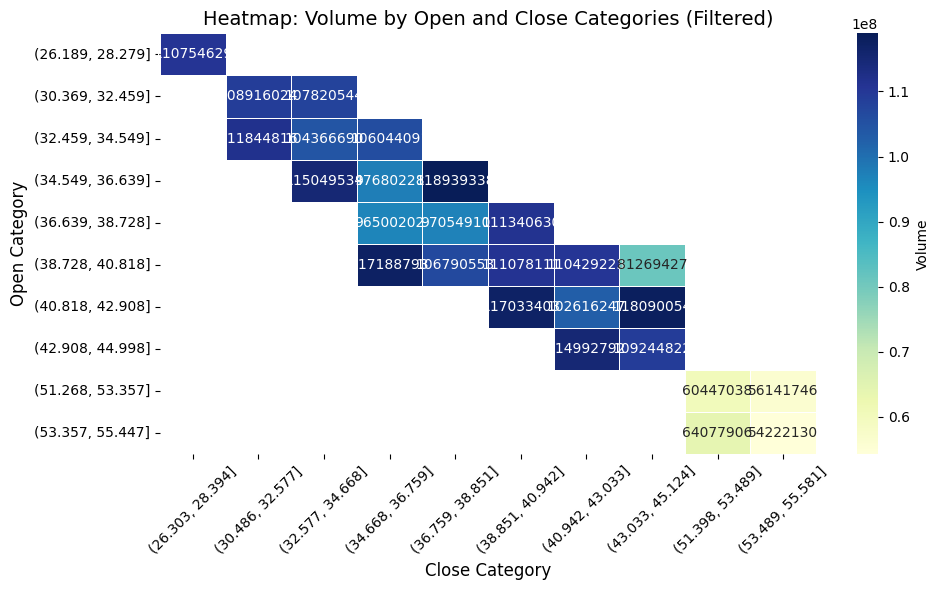

In [9]:
# Select a limited number of categories for better readability
top_open_categories = categorized_df['Open_category'].value_counts().head(10).index  # Top 10 Open categories
top_close_categories = categorized_df['Close_category'].value_counts().head(10).index  # Top 10 Close categories

# Filter the data to include only the selected categories
filtered_data = categorized_df[
    categorized_df['Open_category'].isin(top_open_categories) & 
    categorized_df['Close_category'].isin(top_close_categories)
]

# Create a pivot table for the heatmap
pivot_table = pd.pivot_table(
    filtered_data, 
    values='Volume', 
    index='Open_category', 
    columns='Close_category', 
    aggfunc='mean',  # Aggregate by mean
    observed=False  # Explicitly set observed=False to match the current behavior
)

# Plot the heatmap
plt.figure(figsize=(10, 6))  # Set the figure size
sns.heatmap(
    pivot_table, 
    annot=True,  # Show values inside the heatmap cells
    fmt=".0f",  # Format numbers as integers
    cmap="YlGnBu",  # Choose a color palette
    linewidths=0.5,  # Add lines between cells
    cbar_kws={'label': 'Volume'}  # Add a label to the color bar
)

# Adjust labels and titles
plt.title("Heatmap: Volume by Open and Close Categories (Filtered)", fontsize=14)  # Title of the heatmap
plt.xlabel("Close Category", fontsize=12)  # X-axis label
plt.ylabel("Open Category", fontsize=12)  # Y-axis label
plt.xticks(rotation=45, fontsize=10)  # Rotate X-axis labels for better readability
plt.yticks(fontsize=10)  # Set font size for Y-axis labels
plt.tight_layout()  # Adjust layout to avoid overlap
plt.show()


Strip plot

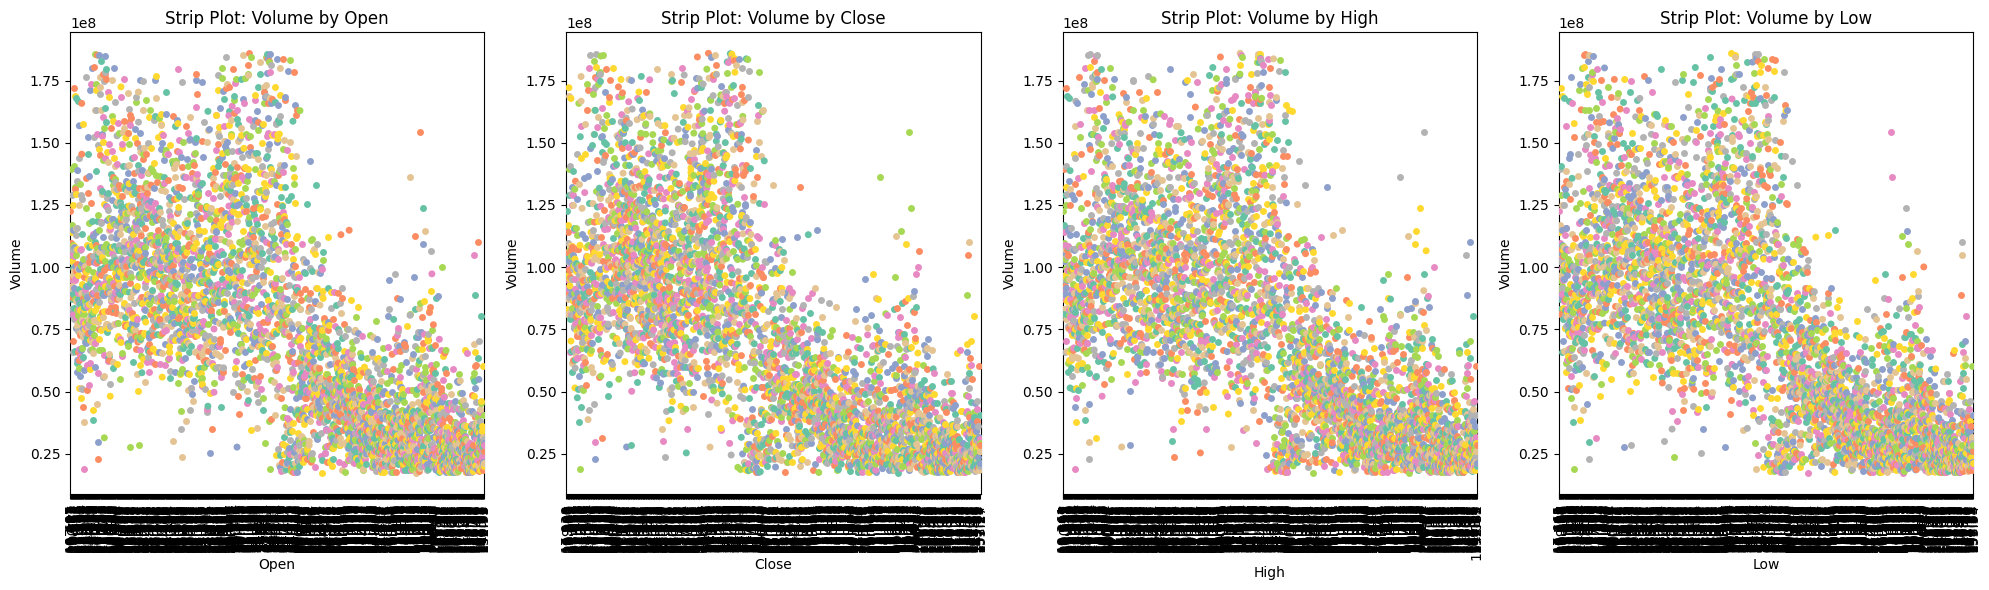

In [10]:
# Filter top categories to show only key intervals
fig, axes = plt.subplots(1, len(columns_to_check), figsize=(20, 6))

for i, column in enumerate(columns_to_check):
    sns.stripplot(
        x=column, y='Volume', data=categorized_df, ax=axes[i], jitter=True, size=5, palette="Set2",  hue=column, dodge=False, legend=False
    )
    axes[i].set_title(f"Strip Plot: Volume by {column}")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Volume")
    
    # Display only every 5th category
    xticks = axes[i].get_xticks()
    axes[i].set_xticks(xticks[::5])  # Show every 5th tick
    axes[i].tick_params(axis='x', rotation=90)

# Adjust layout for better spacing and clarity
plt.tight_layout()
plt.show()


Box Plot

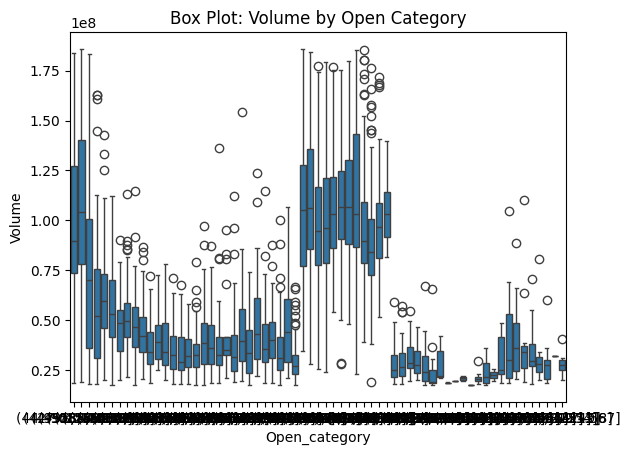

In [11]:
sns.boxplot(x='Open_category', y='Volume', data=categorized_df)
plt.title("Box Plot: Volume by Open Category")
plt.show()

Violin Plot

C:\Users\niush\AppData\Local\Temp\ipykernel_3548\1201455021.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Open_category', y='Volume', data=categorized_df, palette='muted')


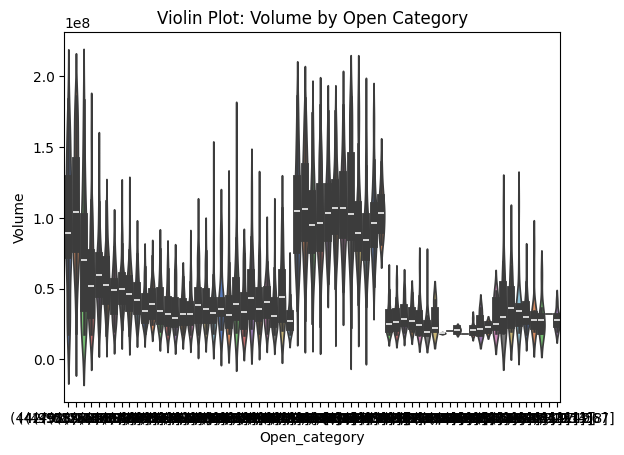

In [12]:
sns.violinplot(x='Open_category', y='Volume', data=categorized_df, palette='muted')
plt.title("Violin Plot: Volume by Open Category")
plt.show()

Using Heatmap for simultaneous display

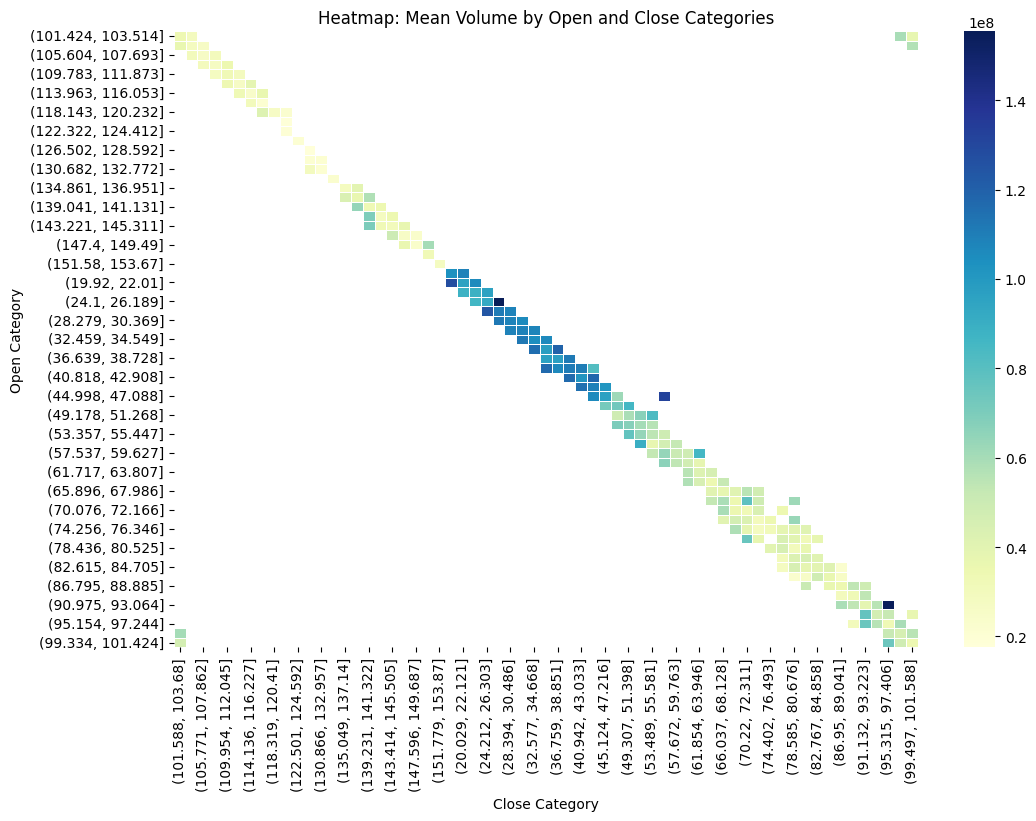

In [13]:
pivot_table = pd.pivot_table(
    categorized_df, 
    values='Volume', 
    index='Open_category', 
    columns='Close_category', 
    aggfunc='mean'
)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=False, cmap="YlGnBu", linewidths=0.5)
plt.title("Heatmap: Mean Volume by Open and Close Categories")
plt.xlabel("Close Category")
plt.ylabel("Open Category")
plt.show()

Displaying data dispersion with Swarm Plot

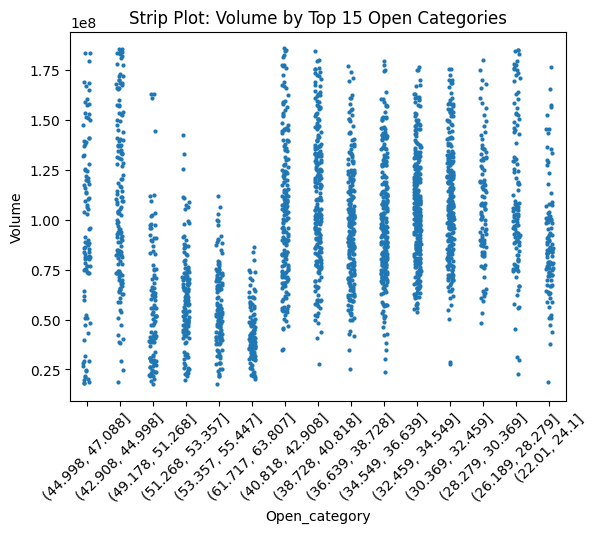

In [14]:
# limited the ctaegories
top_categories = categorized_df['Open_category'].value_counts().head(15).index
filtered_data = categorized_df[categorized_df['Open_category'].isin(top_categories)]

# draw Strip Plot
sns.stripplot(x='Open_category', y='Volume', data=filtered_data, jitter=True, size=3)
plt.title("Strip Plot: Volume by Top 15 Open Categories")
plt.xticks(rotation=45)
plt.show()

Calculating summary statistics for the 65 categories

In [15]:
summary_stats = categorized_df.groupby('Open_category')['Volume'].agg(['mean', 'median', 'std']).sort_values(by='mean', ascending=False)
print(summary_stats.head(10)) 
# show the 10 category with the most avg

                                     mean       median           std
Open_category                                                       
(26.189, 28.279]             1.116205e+08  102991311.0  3.830069e+07
(38.728, 40.818]             1.105361e+08  105991110.0  3.372640e+07
(42.908, 44.998]             1.095183e+08  104016782.0  4.139847e+07
(30.369, 32.459]             1.088171e+08  106719694.5  2.771031e+07
(28.279, 30.369]             1.086020e+08  106818327.0  2.956727e+07
(40.818, 42.908]             1.058305e+08  104926951.5  3.524628e+07
(32.459, 34.549]             1.053056e+08  103110836.0  2.677905e+07
(17.692999999999998, 19.92]  1.038982e+08  103145032.0  1.526957e+07
(34.549, 36.639]             1.003544e+08   96233203.0  3.022035e+07
(19.92, 22.01]               9.892525e+07   96535172.5  2.690120e+07


Bar chart visualization for average or total

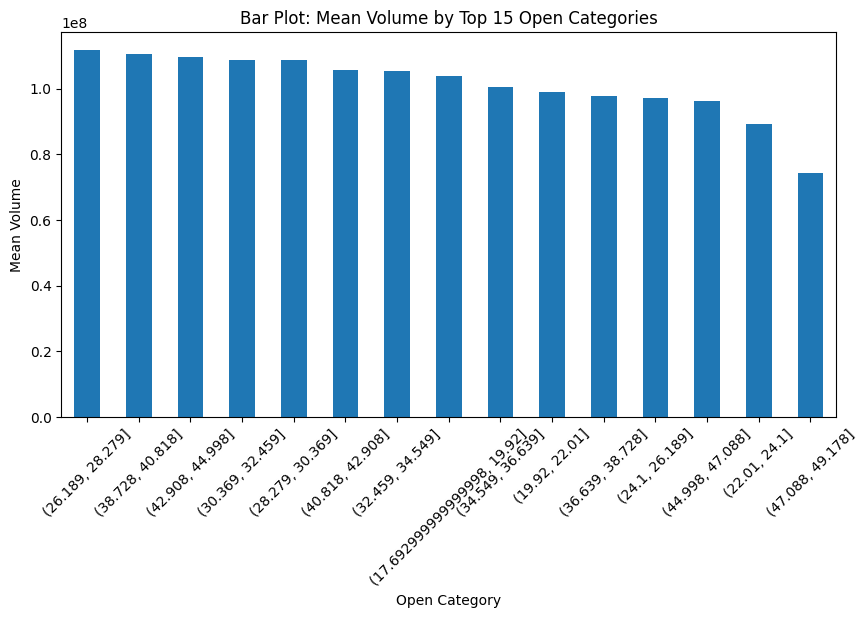

In [16]:
mean_volume = categorized_df.groupby('Open_category')['Volume'].mean().sort_values(ascending=False).head(15)

mean_volume.plot(kind='bar', figsize=(10, 5))
plt.title("Bar Plot: Mean Volume by Top 15 Open Categories")
plt.xlabel("Open Category")
plt.ylabel("Mean Volume")
plt.xticks(rotation=45)
plt.show()

Percentage comparison of categories

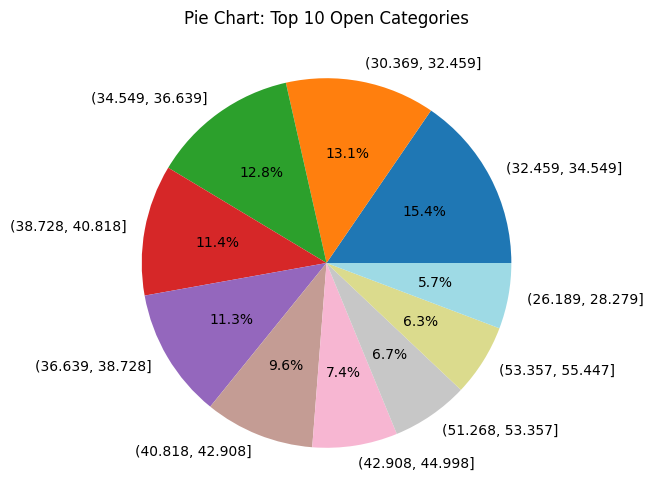

In [17]:
category_percentage = categorized_df['Open_category'].value_counts(normalize=True).head(10)

category_percentage.plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6), colormap='tab20')
plt.title("Pie Chart: Top 10 Open Categories")
plt.ylabel("")
plt.show()